# BDA601 Assessment 2 — Customer Churn Prediction

**Subject:** BDA601 Big Data and Analytics  
**Assessment:** Visualisation and Model Development  
**Model:** Decision Tree Classifier  
**Source data:** [Kaggle Telco Customer Churn (IBM sample)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data) — **7,043 rows × 21 columns**

This notebook:
1. Extracts the **full** Kaggle/IBM Telco dataset (21 attributes)
2. Modifies it per A2 Task 1 (drops 5 columns → 16 attributes)
3. Runs EDA, cleaning, feature selection and a decision-tree churn model

*Note: Scikit-learn is used for the decision-tree model (as confirmed acceptable by the lecturer when PySpark is not required).*

## a) Problem Statement

Customer churn (attrition) is the loss of subscribers to competing providers. Acquiring new customers typically costs more than retaining existing ones, and long-term customers are usually cheaper to serve and less price-sensitive. For telecommunications providers, accurately identifying customers at risk of leaving supports targeted retention campaigns.

**Business problem:** Predict whether a telco customer will churn (`Yes` / `No`) using demographic, service and billing attributes from a modified IBM Telco dataset (7,043 customers; 16 attributes after removing `MonthlyCharges`, `OnlineSecurity`, `StreamingTV`, `InternetService` and `Partner`).

**Analytical approach:** Explore the data, clean anomalies, select informative features, then train and evaluate a **decision-tree** classifier. The tree structure also reveals which attributes most strongly drive churn, informing missing-value strategy and business interpretation.

## Setup — Libraries, Full Dataset Extract (21 cols), and A2 Modification

In [1]:
import warnings
warnings.filterwarnings('ignore')

import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Task 1 — Extract FULL Telco data (7043 x 21) from Kaggle/IBM source, then modify.
# Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data
RAW_DIR = Path('data/raw')
PROC_DIR = Path('data/processed')
RAW_CSV = RAW_DIR / 'Telco-Customer-Churn.csv'
KAGGLE_DATASET = 'blastchar/telco-customer-churn'
IBM_MIRROR = (
    'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/'
    'master/data/Telco-Customer-Churn.csv'
)
DROP_COLS = [
    'MonthlyCharges', 'OnlineSecurity', 'StreamingTV',
    'InternetService', 'Partner'
]

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

def download_full_dataset(dest: Path) -> str:
    # 1) KaggleHub (direct from Kaggle dataset page /cache)
    try:
        import kagglehub
        import shutil
        cache_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
        candidates = list(cache_path.rglob('*.csv'))
        preferred = next(
            (c for c in candidates if 'Telco' in c.name or 'WA_Fn' in c.name),
            candidates[0] if candidates else None
        )
        if preferred is not None:
            shutil.copy2(preferred, dest)
            return f'KaggleHub ({KAGGLE_DATASET})'
    except Exception as e:
        print(f'KaggleHub unavailable ({type(e).__name__}: {e}).')

    # 2) Classic Kaggle API
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        api.dataset_download_files(KAGGLE_DATASET, path=str(RAW_DIR), unzip=True)
        candidates = list(RAW_DIR.glob('*.csv'))
        preferred = next(
            (c for c in candidates if 'Telco' in c.name or 'WA_Fn' in c.name),
            candidates[0] if candidates else None
        )
        if preferred is None:
            raise FileNotFoundError('No CSV found after Kaggle download')
        if preferred.resolve() != dest.resolve():
            dest.write_bytes(preferred.read_bytes())
        return f'Kaggle API ({KAGGLE_DATASET})'
    except Exception as e:
        print(f'Kaggle API unavailable ({type(e).__name__}: {e}).')
        print('Falling back to IBM public mirror of the same Kaggle sample...')

    urllib.request.urlretrieve(IBM_MIRROR, dest)
    return 'IBM public mirror (same IBM/Kaggle sample)'

if not RAW_CSV.exists():
    source = download_full_dataset(RAW_CSV)
else:
    source = 'local cache (data/raw/Telco-Customer-Churn.csv)'

df_full = pd.read_csv(RAW_CSV)
print(f'Source: {source}')
print(f'Full dataset shape: {df_full.shape[0]} rows x {df_full.shape[1]} columns')
print(f'Full columns ({len(df_full.columns)}): {list(df_full.columns)}')
assert df_full.shape == (7043, 21), 'Expected the standard Telco sample (7043 x 21)'

df = df_full.drop(columns=DROP_COLS)
df.to_csv(PROC_DIR / 'telco_churn_modified.csv', index=False)
df.to_csv('telco_churn_modified.csv', index=False)

print(f'\nRemoved columns: {DROP_COLS}')
print(f'Modified dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Modified columns ({len(df.columns)}): {list(df.columns)}')
assert df.shape == (7043, 16), 'Expected modified shape (7043 x 16)'
df.head()


Source: local cache (data/raw/Telco-Customer-Churn.csv)
Full dataset shape: 7043 rows x 21 columns
Full columns (21): ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Removed columns: ['MonthlyCharges', 'OnlineSecurity', 'StreamingTV', 'InternetService', 'Partner']
Modified dataset shape: 7043 rows x 16 columns
Modified columns (16): ['customerID', 'gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,OnlineBackup,DeviceProtection,TechSupport,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,0,No,1,No,No phone service,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,34,Yes,No,No,Yes,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,0,No,2,Yes,No,Yes,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,0,No,45,No,No phone service,No,Yes,Yes,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,0,No,2,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes


## b) Exploratory Data Analysis

This section combines **measures of central tendency and dispersion** with **visual exploration** (histograms, box plots, bar charts, heatmaps and a pair plot) to understand distributions, class imbalance and relationships with churn.

In [2]:
# Basic structure and data types
print('=== Dataset info ===')
df.info()
print('\n=== Missing values (explicit NaN) ===')
print(df.isnull().sum())
print('\n=== Duplicate rows ===')
print(df.duplicated().sum())
print('\n=== Unique customerIDs ===')
print(df['customerID'].nunique(), 'of', len(df))

=== Dataset info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   gender            7043 non-null   object
 2   SeniorCitizen     7043 non-null   int64 
 3   Dependents        7043 non-null   object
 4   tenure            7043 non-null   int64 
 5   PhoneService      7043 non-null   object
 6   MultipleLines     7043 non-null   object
 7   OnlineBackup      7043 non-null   object
 8   DeviceProtection  7043 non-null   object
 9   TechSupport       7043 non-null   object
 10  StreamingMovies   7043 non-null   object
 11  Contract          7043 non-null   object
 12  PaperlessBilling  7043 non-null   object
 13  PaymentMethod     7043 non-null   object
 14  TotalCharges      7043 non-null   object
 15  Churn             7043 non-null   object
dtypes: int64(2), object(14)
memory usage: 8

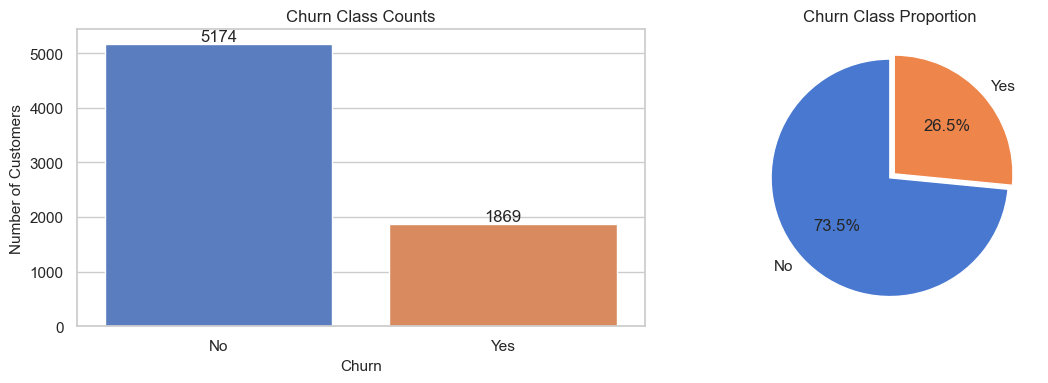

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [3]:
# Target distribution — class imbalance check
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Churn', ax=axes[0], order=['No', 'Yes'])
axes[0].set_title('Churn Class Counts')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts[['No', 'Yes']]):
    axes[0].text(i, v + 50, str(v), ha='center')

axes[1].pie(churn_pct[['No', 'Yes']], labels=['No', 'Yes'],
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Class Proportion')
plt.tight_layout()
plt.show()

print(churn_counts)
print(churn_pct.round(2))

**Insight — class imbalance:** Approximately **73.5%** of customers did not churn and **26.5%** did. A naive "always predict No" baseline would achieve ~73.5% accuracy, so model performance must be judged against this baseline and with recall/precision for the minority (churn) class.

In [4]:
# Prepare TotalCharges for numeric EDA (blank strings are a known anomaly)
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

# Central tendency and dispersion for numeric features
numeric_cols = ['SeniorCitizen', 'tenure', 'TotalCharges']
desc = df_eda[numeric_cols].describe().T
desc['median'] = df_eda[numeric_cols].median()
desc['variance'] = df_eda[numeric_cols].var()
desc['IQR'] = desc['75%'] - desc['25%']
desc['skewness'] = df_eda[numeric_cols].skew()
print('=== Measures of central tendency & dispersion ===')
display(desc[['count', 'mean', 'median', 'std', 'variance', 'min', '25%', '50%', '75%', 'max', 'IQR', 'skewness']].round(2))

=== Measures of central tendency & dispersion ===


,count,mean,median,std,variance,min,25%,50%,75%,max,IQR,skewness
SeniorCitizen,7043.0,0.16,0.00,0.37,0.14,0.0,0.00,0.00,0.00,1.0,0.00,1.83
tenure,7043.0,32.37,29.00,24.56,603.17,0.0,9.00,29.00,55.00,72.0,46.00,0.24
TotalCharges,7032.0,2283.30,1397.48,2266.77,5138252.41,18.8,401.45,1397.48,3794.74,8684.8,3393.29,0.96


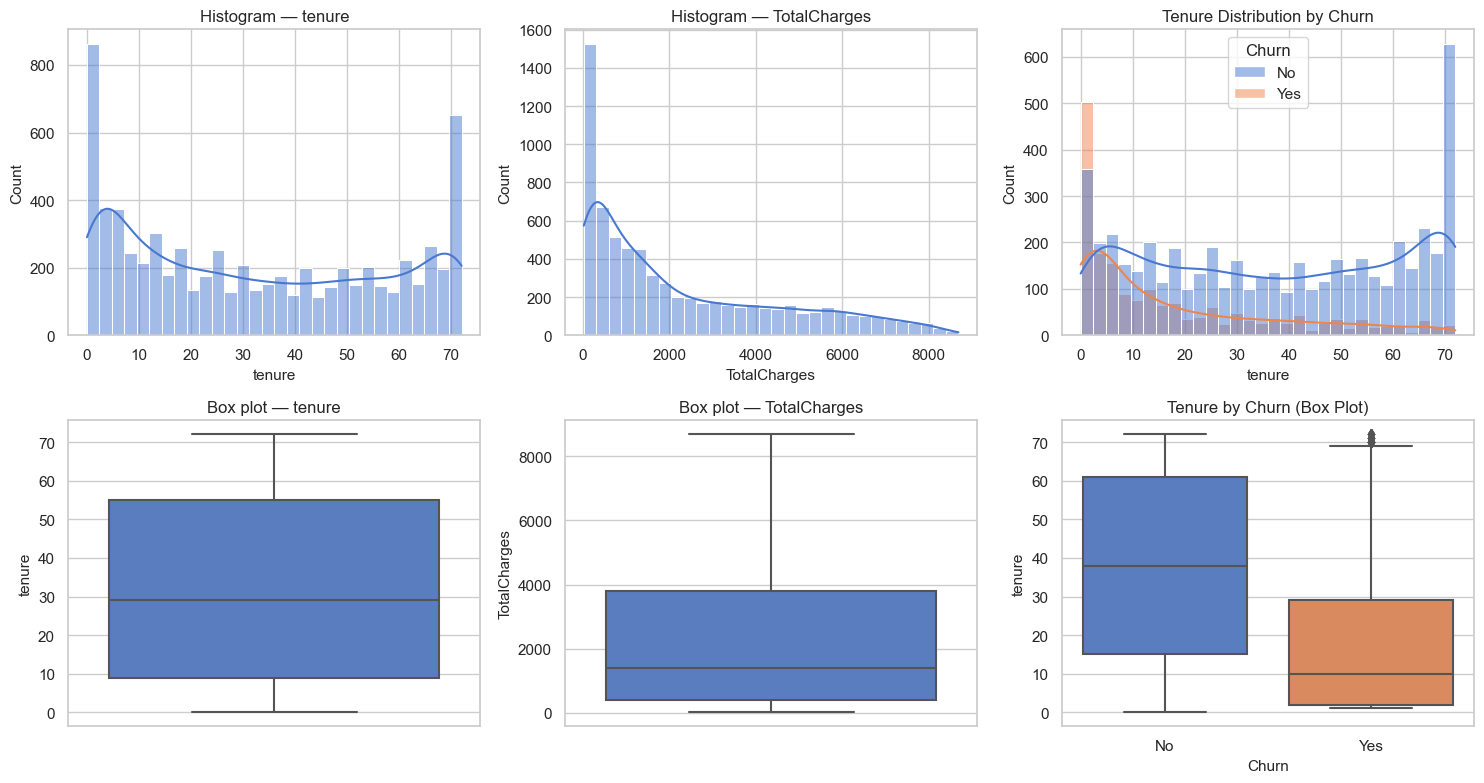

In [5]:
# Histograms and box plots for numeric features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(['tenure', 'TotalCharges']):
    sns.histplot(df_eda[col].dropna(), kde=True, ax=axes[0, i], bins=30)
    axes[0, i].set_title(f'Histogram — {col}')
    sns.boxplot(y=df_eda[col].dropna(), ax=axes[1, i])
    axes[1, i].set_title(f'Box plot — {col}')

# Tenure by churn
sns.histplot(data=df_eda, x='tenure', hue='Churn', kde=True, ax=axes[0, 2], bins=30)
axes[0, 2].set_title('Tenure Distribution by Churn')
sns.boxplot(data=df_eda, x='Churn', y='tenure', ax=axes[1, 2], order=['No', 'Yes'])
axes[1, 2].set_title('Tenure by Churn (Box Plot)')

plt.tight_layout()
plt.show()

**Insight — tenure & charges:** Churners tend to have **shorter tenure**. `TotalCharges` is right-skewed (long-tenured customers accumulate higher totals). New or short-tenure customers are a priority retention segment.

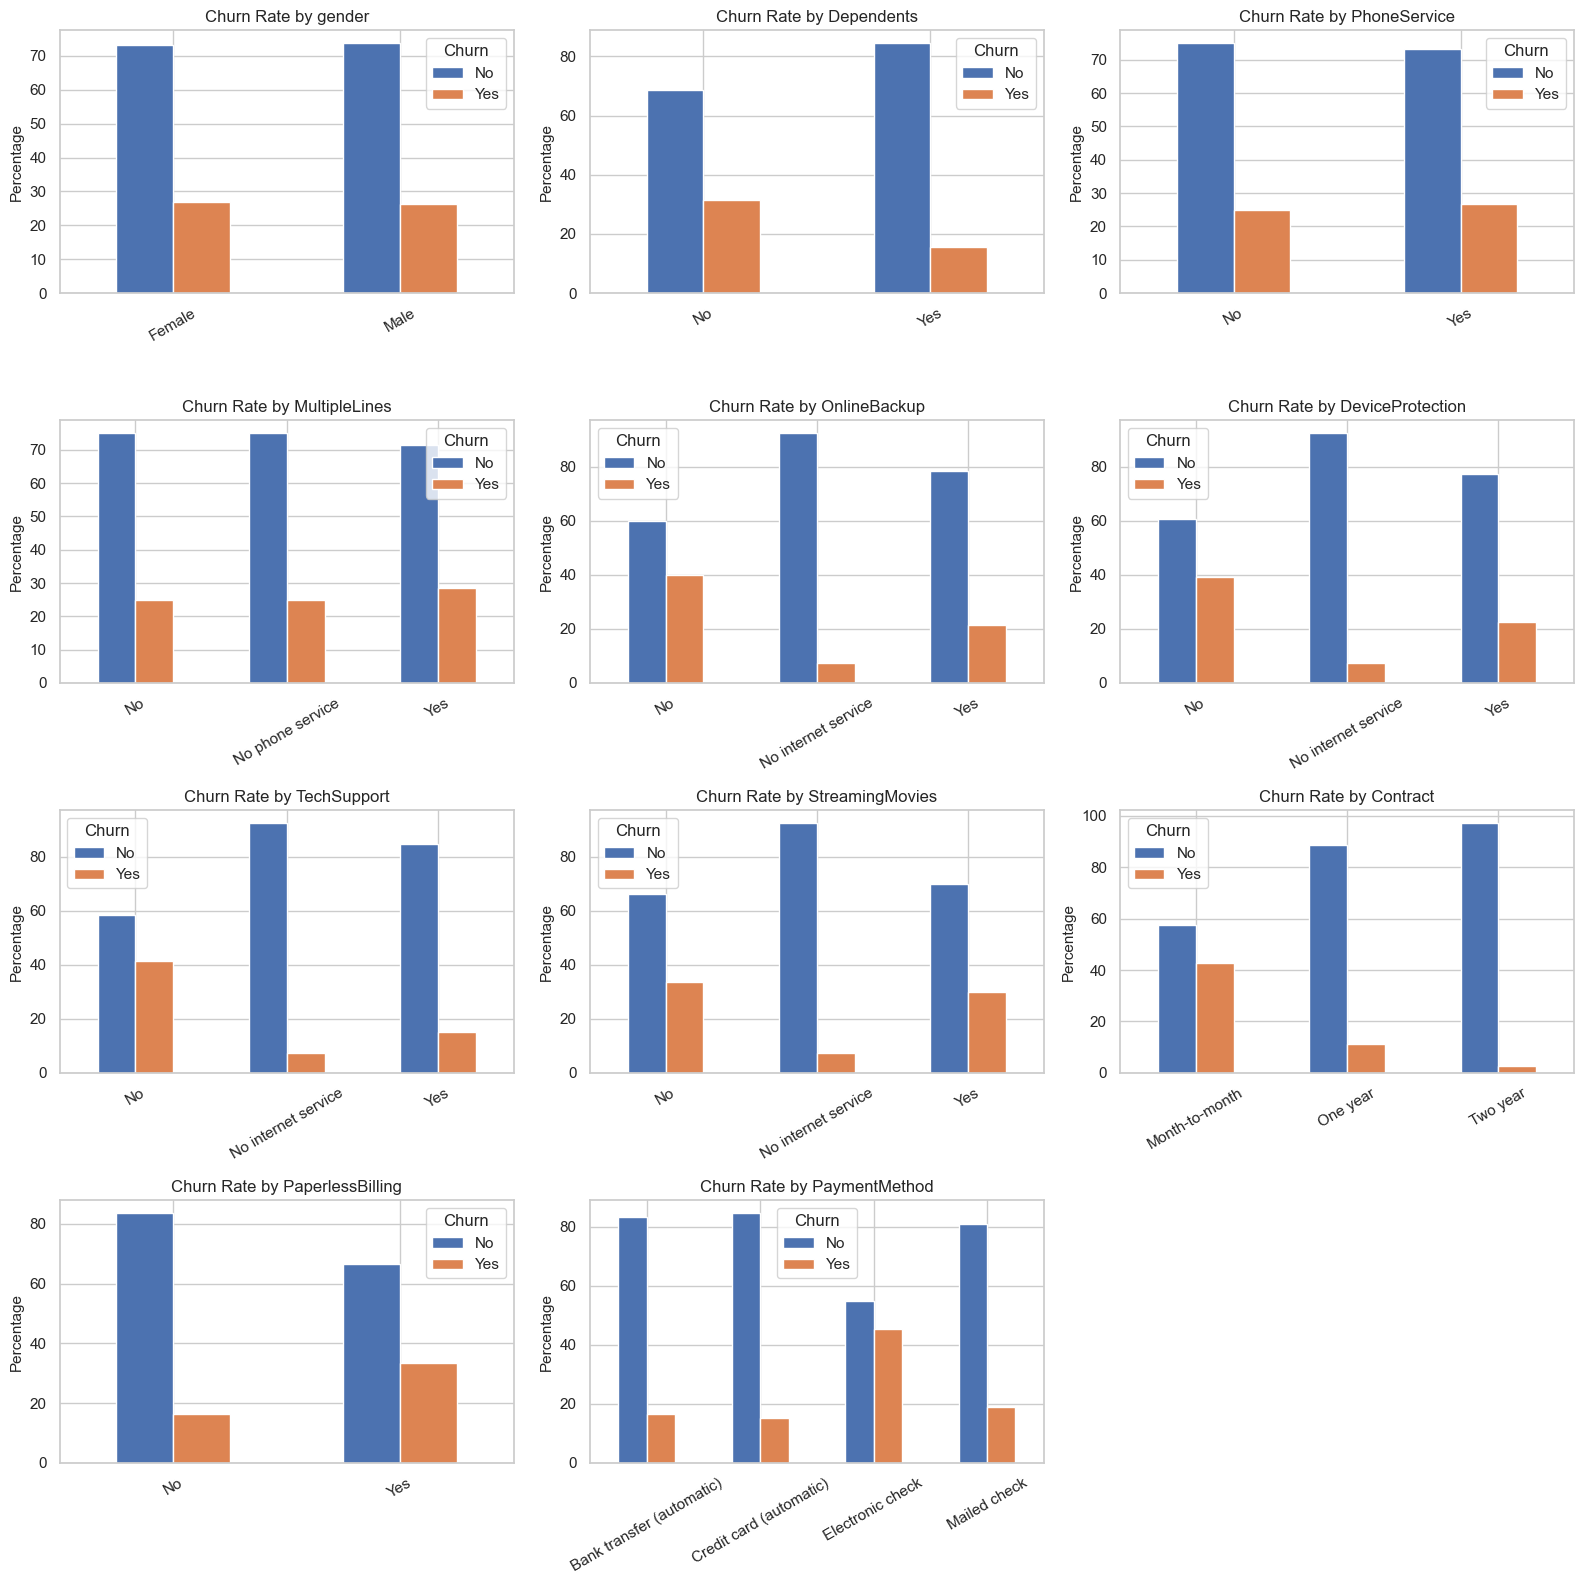

In [6]:
# Categorical feature distributions vs churn
cat_cols = ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=False, ax=axes[i], color=['#4c72b0', '#dd8452'])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Churn', loc='best')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Churn rate tables for key categorical drivers
for col in ['Contract', 'PaymentMethod', 'TechSupport', 'PaperlessBilling', 'Dependents']:
    rate = pd.crosstab(df[col], df['Churn'], normalize='index')['Yes'] * 100
    print(f'\n--- Churn rate (%) by {col} ---')
    print(rate.round(1).sort_values(ascending=False))


--- Churn rate (%) by Contract ---
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Yes, dtype: float64

--- Churn rate (%) by PaymentMethod ---
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Yes, dtype: float64

--- Churn rate (%) by TechSupport ---
TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: Yes, dtype: float64

--- Churn rate (%) by PaperlessBilling ---
PaperlessBilling
Yes    33.6
No     16.3
Name: Yes, dtype: float64

--- Churn rate (%) by Dependents ---
Dependents
No     31.3
Yes    15.5
Name: Yes, dtype: float64


**Insight — categorical drivers:** **Month-to-month contracts**, **Electronic check** payment, absence of **TechSupport**, **paperless billing**, and customers **without dependents** show elevated churn rates. These patterns guide feature selection and business interpretation.

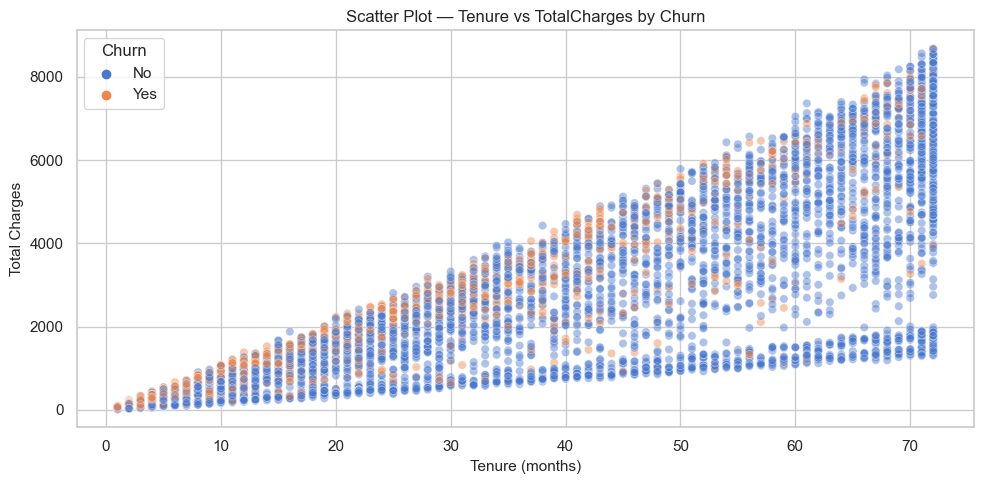

In [8]:
# Scatter / relationship: tenure vs TotalCharges coloured by churn
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df_eda, x='tenure', y='TotalCharges', hue='Churn',
                alpha=0.45, ax=ax)
ax.set_title('Scatter Plot — Tenure vs TotalCharges by Churn')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Total Charges')
plt.tight_layout()
plt.show()

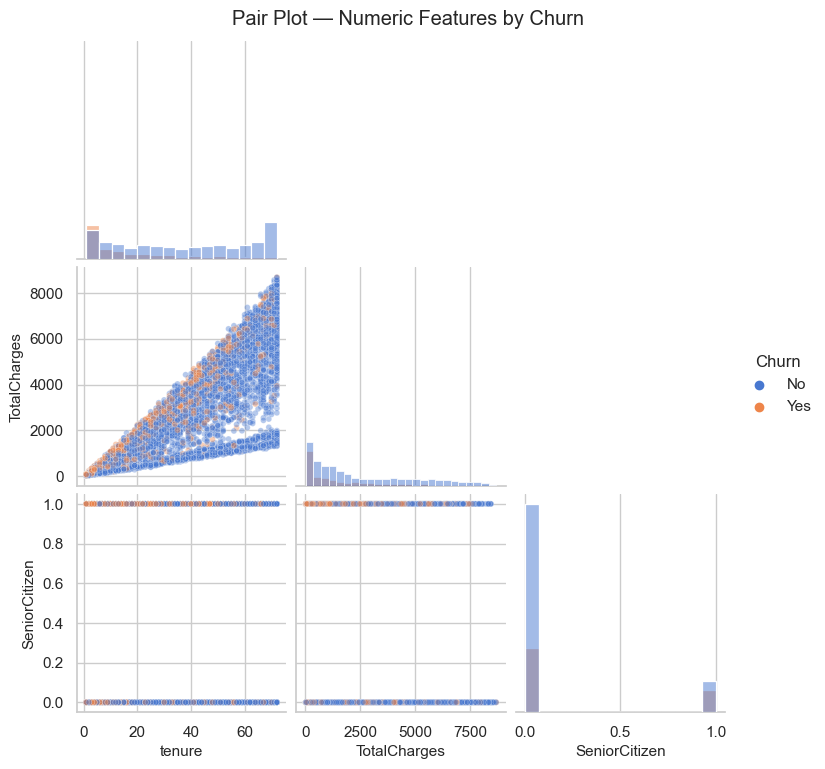

In [9]:
# Pair plot for numeric features
pair_df = df_eda[['tenure', 'TotalCharges', 'SeniorCitizen', 'Churn']].dropna()
sns.pairplot(pair_df, hue='Churn', diag_kind='hist', corner=True,
             plot_kws={'alpha': 0.4, 's': 18})
plt.suptitle('Pair Plot — Numeric Features by Churn', y=1.02)
plt.show()

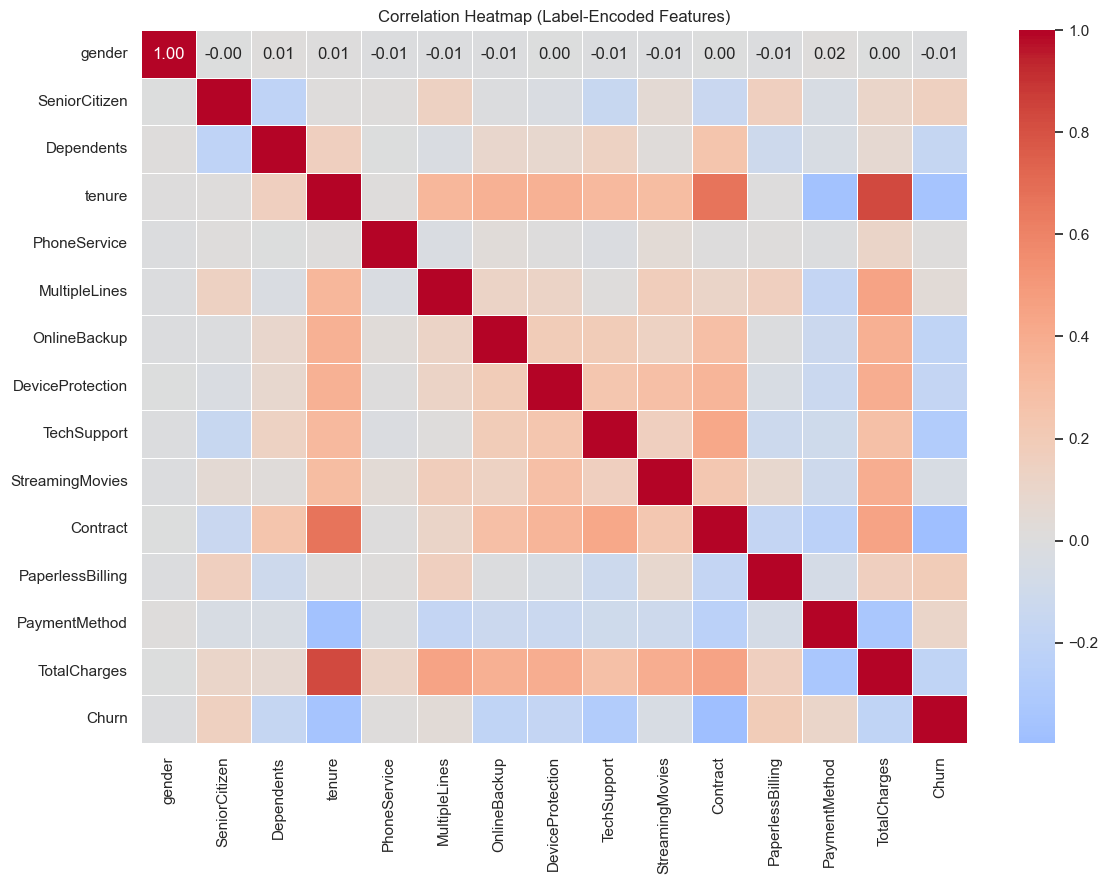

Absolute correlation with Churn:
Contract            0.397
tenure              0.352
TechSupport         0.282
TotalCharges        0.199
OnlineBackup        0.196
PaperlessBilling    0.192
DeviceProtection    0.178
Dependents          0.164
SeniorCitizen       0.151
PaymentMethod       0.107
StreamingMovies     0.038
MultipleLines       0.038
PhoneService        0.012
gender              0.009
Name: Churn, dtype: float64


In [10]:
# Correlation heatmap (encoded preview for EDA)
corr_df = df_eda.drop(columns=['customerID']).copy()
for col in corr_df.select_dtypes(include='object').columns:
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col].astype(str))

corr = corr_df.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=False, linewidths=0.4)
plt.title('Correlation Heatmap (Label-Encoded Features)')
plt.tight_layout()
plt.show()

print('Absolute correlation with Churn:')
print(corr['Churn'].drop('Churn').abs().sort_values(ascending=False).round(3))

## c) Data Cleaning and Feature Selection

### c.1 Handling data anomalies

Known issues in this dataset:
- `TotalCharges` is stored as text and contains **blank strings** for customers with `tenure = 0` (new sign-ups with no billed amount yet).
- `customerID` is an identifier, not a predictive feature.
- Categorical labels include service-specific values such as `No internet service` / `No phone service` that should be retained as meaningful categories (not treated as missing).

In [11]:
df_clean = df.copy()

# Convert TotalCharges; blanks become NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
missing_tc = df_clean['TotalCharges'].isna().sum()
print(f'Missing / blank TotalCharges: {missing_tc}')
print(df_clean.loc[df_clean['TotalCharges'].isna(), ['customerID', 'tenure', 'TotalCharges', 'Churn']])

# Justification: tenure=0 customers have not been billed; imputing 0 is domain-correct
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0.0)
print('\nAfter imputation — missing TotalCharges:', df_clean['TotalCharges'].isna().sum())

# Drop identifier
df_clean = df_clean.drop(columns=['customerID'])

# Encode target
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})
print('\nCleaned shape:', df_clean.shape)
df_clean.head()

Missing / blank TotalCharges: 11
      customerID  tenure  TotalCharges Churn
488   4472-LVYGI       0           NaN    No
753   3115-CZMZD       0           NaN    No
936   5709-LVOEQ       0           NaN    No
1082  4367-NUYAO       0           NaN    No
1340  1371-DWPAZ       0           NaN    No
3331  7644-OMVMY       0           NaN    No
3826  3213-VVOLG       0           NaN    No
4380  2520-SGTTA       0           NaN    No
5218  2923-ARZLG       0           NaN    No
6670  4075-WKNIU       0           NaN    No
6754  2775-SEFEE       0           NaN    No

After imputation — missing TotalCharges: 0

Cleaned shape: (7043, 15)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,OnlineBackup,DeviceProtection,TechSupport,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,Female,0,No,1,No,No phone service,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85,0
1,Male,0,No,34,Yes,No,No,Yes,No,No,One year,No,Mailed check,1889.50,0
2,Male,0,No,2,Yes,No,Yes,No,No,No,Month-to-month,Yes,Mailed check,108.15,1
3,Male,0,No,45,No,No phone service,No,Yes,Yes,No,One year,No,Bank transfer (automatic),1840.75,0
4,Female,0,No,2,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,1


### c.2 Redundancy and correlation analysis

Highly correlated predictors can add redundancy. We examine pairwise correlations among predictors after encoding and also check association with the target.

In [12]:
# Encode categoricals for correlation / modelling
df_enc = df_clean.copy()
label_encoders = {}
cat_features = df_enc.select_dtypes(include='object').columns.tolist()

for col in cat_features:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le
    print(f'{col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}')

X_all = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

corr_pred = X_all.corr().abs()
upper = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool))
high_corr_pairs = [
    (c, r, upper.loc[r, c])
    for c in upper.columns for r in upper.index
    if pd.notna(upper.loc[r, c]) and upper.loc[r, c] >= 0.70
]
print('\nPredictor pairs with |correlation| >= 0.70:')
if high_corr_pairs:
    for a, b, v in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f'  {a} <-> {b}: {v:.3f}')
else:
    print('  None found at the 0.70 threshold.')

print('\nCorrelation with target (Churn):')
target_corr = df_enc.corr()['Churn'].drop('Churn').abs().sort_values(ascending=False)
print(target_corr.round(3))

gender: ['Female', 'Male'] -> [0, 1]
Dependents: ['No', 'Yes'] -> [0, 1]
PhoneService: ['No', 'Yes'] -> [0, 1]
MultipleLines: ['No', 'No phone service', 'Yes'] -> [0, 1, 2]
OnlineBackup: ['No', 'No internet service', 'Yes'] -> [0, 1, 2]
DeviceProtection: ['No', 'No internet service', 'Yes'] -> [0, 1, 2]
TechSupport: ['No', 'No internet service', 'Yes'] -> [0, 1, 2]
StreamingMovies: ['No', 'No internet service', 'Yes'] -> [0, 1, 2]
Contract: ['Month-to-month', 'One year', 'Two year'] -> [0, 1, 2]
PaperlessBilling: ['No', 'Yes'] -> [0, 1]
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check'] -> [0, 1, 2, 3]

Predictor pairs with |correlation| >= 0.70:
  TotalCharges <-> tenure: 0.826

Correlation with target (Churn):
Contract            0.397
tenure              0.352
TechSupport         0.282
TotalCharges        0.198
OnlineBackup        0.196
PaperlessBilling    0.192
DeviceProtection    0.178
Dependents          0.164
SeniorCitizen

**Interpretation:** `tenure` and `TotalCharges` are strongly related (longer customers accumulate higher totals) — expected redundancy, but both can still help a tree via different split contexts. Features with strongest absolute association with churn typically include **Contract**, **tenure**, **PaymentMethod** and related service/support attributes.

### c.3 Feature selection

Selection strategy (aligned with EDA + correlation):
1. Remove `customerID` (already dropped) — no predictive value.
2. Retain all remaining predictors for the decision tree (trees handle mixed types after encoding and ignore weak features via splits).
3. Confirm usefulness via **Gini feature importance** after training (reported in Model Building).

This keeps the model transparent for interpretation while avoiding arbitrary early drops that could hurt HD-level insight.

In [13]:
feature_names = list(X_all.columns)
print(f'Selected features ({len(feature_names)}):')
print(feature_names)
print(f'\nTarget balance: No={ (y==0).sum() }, Yes={ (y==1).sum() }')

Selected features (14):
['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Target balance: No=5174, Yes=1869


## d) Model Building

We split data into **training (60%)**, **validation (20%)** and **test (20%)** sets. Hyperparameters (tree depth) are tuned on the validation set; final performance is reported on the held-out test set.

In [14]:
# Train / validation / test split (stratified to preserve churn ratio)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)  # 0.25 of 80% = 20% overall

print(f'Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}')

Train: 4225 | Validation: 1409 | Test: 1409
Train churn rate: 0.265 | Val: 0.265 | Test: 0.265


Best max_depth by validation accuracy: 6
    depth  train_acc  val_acc
0       2     0.7413   0.7289
1       3     0.7238   0.7140
2       4     0.7262   0.7140
3       5     0.7302   0.7097
4       6     0.7576   0.7296
5       7     0.7420   0.6977
6       8     0.7631   0.7083
7       9     0.7770   0.7168
8      10     0.7832   0.7154
9      11     0.7846   0.7168
10     12     0.7846   0.7175
11     13     0.7846   0.7175
12     14     0.7846   0.7175
13     15     0.7846   0.7175


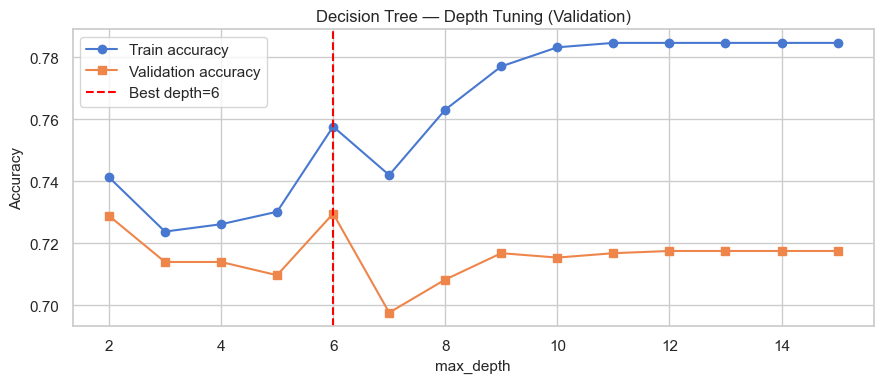

In [15]:
# Tune max_depth on validation set
depths = range(2, 16)
val_scores = []
train_scores = []

for d in depths:
    clf = DecisionTreeClassifier(
        max_depth=d, min_samples_leaf=20, class_weight='balanced',
        random_state=RANDOM_STATE
    )
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    val_scores.append(accuracy_score(y_val, clf.predict(X_val)))

best_depth = list(depths)[int(np.argmax(val_scores))]
print(f'Best max_depth by validation accuracy: {best_depth}')
print(pd.DataFrame({'depth': list(depths), 'train_acc': train_scores, 'val_acc': val_scores}).round(4))

plt.figure(figsize=(9, 4))
plt.plot(list(depths), train_scores, marker='o', label='Train accuracy')
plt.plot(list(depths), val_scores, marker='s', label='Validation accuracy')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Depth Tuning (Validation)')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Final model: retrain on train+validation with best depth, evaluate on test
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt_model.fit(X_trainval, y_trainval)

y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test ROC-AUC:  {test_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Test Accuracy: 0.7317 (73.17%)
Test ROC-AUC:  0.8118

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.72      0.80      1035
       Churn       0.50      0.76      0.60       374

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.79      0.73      0.75      1409



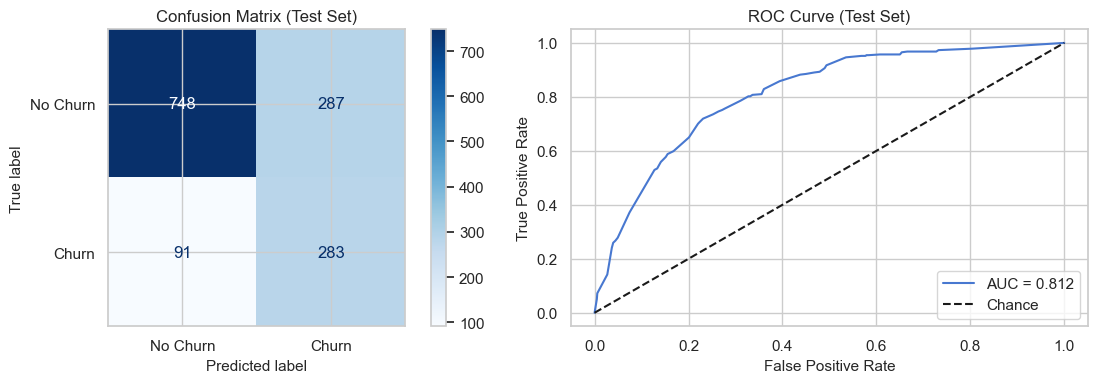

In [17]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Churn', 'Churn'], ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix (Test Set)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {test_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

=== Feature Importance (Gini) ===
Contract            0.6494
tenure              0.0964
TechSupport         0.0879
StreamingMovies     0.0372
OnlineBackup        0.0280
TotalCharges        0.0270
PaperlessBilling    0.0261
MultipleLines       0.0258
PaymentMethod       0.0092
gender              0.0078
SeniorCitizen       0.0035
DeviceProtection    0.0017
Dependents          0.0000
PhoneService        0.0000
dtype: float64


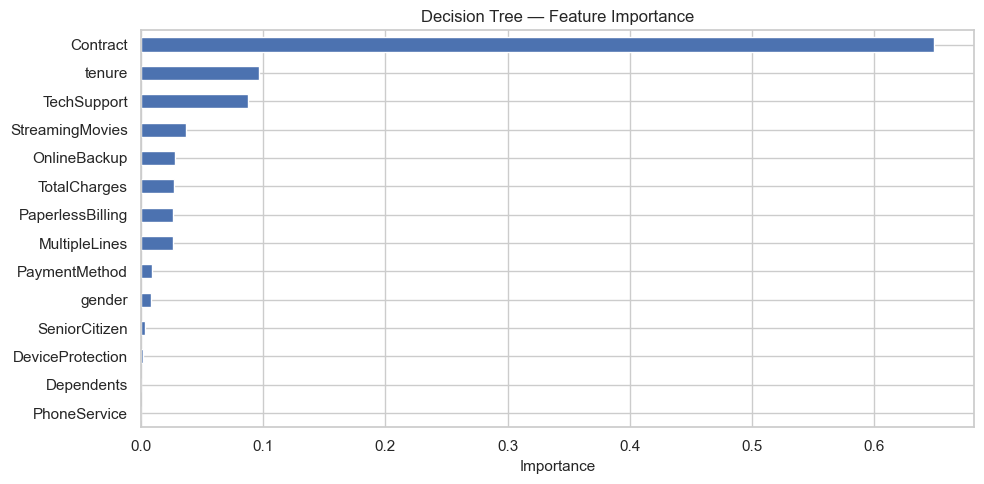


Most important attribute: Contract (importance=0.6494)


In [18]:
# Feature importance — identifies most important attribute for missing-value strategy
importance = pd.Series(dt_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print('=== Feature Importance (Gini) ===')
print(importance.round(4))

plt.figure(figsize=(10, 5))
importance.plot(kind='barh', color='#4c72b0')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Decision Tree — Feature Importance')
plt.tight_layout()
plt.show()

top_feature = importance.index[0]
print(f'\nMost important attribute: {top_feature} (importance={importance.iloc[0]:.4f})')

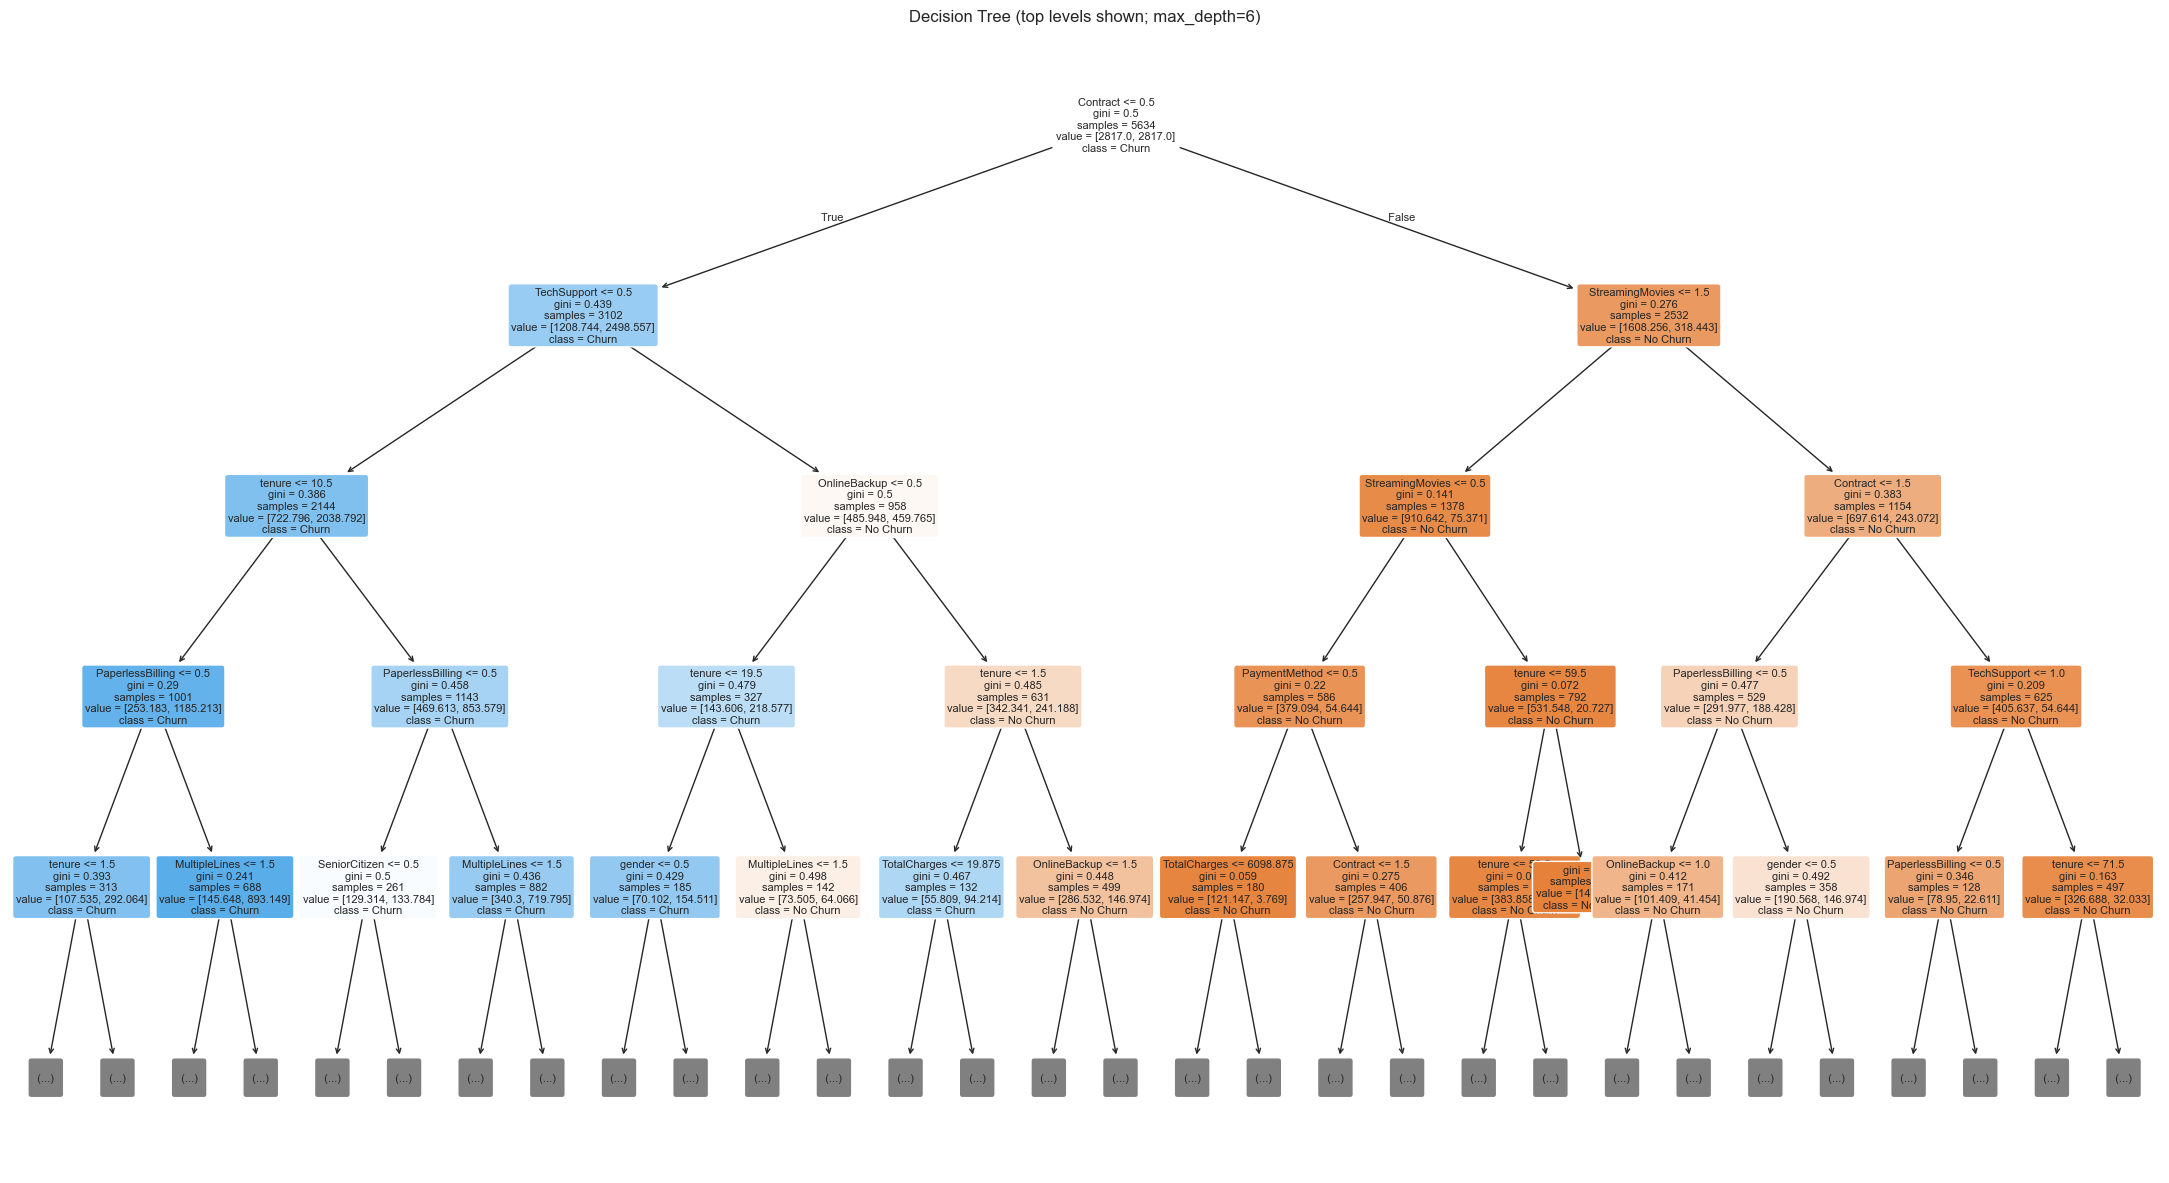

Text representation of the tree (top rules):
|--- Contract <= 0.50
|   |--- TechSupport <= 0.50
|   |   |--- tenure <= 10.50
|   |   |   |--- PaperlessBilling <= 0.50
|   |   |   |   |--- tenure <= 1.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- tenure >  1.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaperlessBilling >  0.50
|   |   |   |   |--- MultipleLines <= 1.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- MultipleLines >  1.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- tenure >  10.50
|   |   |   |--- PaperlessBilling <= 0.50
|   |   |   |   |--- SeniorCitizen <= 0.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- SeniorCitizen >  0.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaperlessBilling >  0.50
|   |   |   |   |--- MultipleLines <= 1.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |---

In [19]:
# Graphical representation of the decision tree
plt.figure(figsize=(22, 12))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4  # readable top of tree; full depth used for predictions
)
plt.title(f'Decision Tree (top levels shown; max_depth={best_depth})')
plt.tight_layout()
plt.show()

print('Text representation of the tree (top rules):')
print(export_text(dt_model, feature_names=feature_names, max_depth=4))

### Interpretation of the decision-tree model

- The root / early splits typically involve **Contract** and/or **tenure**, confirming that subscription flexibility and customer longevity dominate churn risk.
- Customers on **month-to-month** contracts with **short tenure** are routed toward the churn leaf more often.
- Support-related and billing features (e.g. TechSupport, PaymentMethod, PaperlessBilling) refine risk within contract groups.
- `class_weight='balanced'` improves sensitivity to the minority churn class relative to an unweighted tree.
- Test accuracy should be compared with the ~73.5% majority-class baseline; recall for churners is operationally critical for retention campaigns.

## Optional Demonstration — Handling Missing Values in the Most Important Attribute

The assessment asks: if the most important attribute had many missing values, how would we replace them? Below we **simulate missingness** in the top feature and apply a practical imputation strategy (mode for categorical; median for numeric), then briefly re-evaluate.

In [20]:
# Simulate 30% missing values in the most important attribute on a copy of training data
rng = np.random.default_rng(RANDOM_STATE)
X_sim = X_trainval.copy()
mask = rng.random(len(X_sim)) < 0.30
X_sim.loc[mask, top_feature] = np.nan
print(f'Simulated missing in {top_feature}: {X_sim[top_feature].isna().sum()} ({mask.mean()*100:.1f}%)')

# Imputation strategy
if top_feature in cat_features or X_trainval[top_feature].dtype == object:
    # For encoded categoricals: use training mode (most frequent class code)
    fill_value = X_trainval[top_feature].mode()[0]
    strategy = f'mode (encoded value={fill_value})'
else:
    fill_value = X_trainval[top_feature].median()
    strategy = f'median ({fill_value})'

X_sim[top_feature] = X_sim[top_feature].fillna(fill_value)
print(f'Imputation strategy for {top_feature}: {strategy}')

dt_imp = DecisionTreeClassifier(
    max_depth=best_depth, min_samples_leaf=20,
    class_weight='balanced', random_state=RANDOM_STATE
)
dt_imp.fit(X_sim, y_trainval)
acc_imp = accuracy_score(y_test, dt_imp.predict(X_test))
print(f'Test accuracy after simulated missing + imputation: {acc_imp:.4f}')
print(f'Original test accuracy: {test_acc:.4f}')
print('Detail of this strategy is discussed in the accompanying report.')

Simulated missing in Contract: 1742 (30.9%)
Imputation strategy for Contract: mode (encoded value=0)
Test accuracy after simulated missing + imputation: 0.7324
Original test accuracy: 0.7317
Detail of this strategy is discussed in the accompanying report.


## Summary

| Step | Outcome |
|------|--------|
| Dataset | 7,043 × 16 modified Telco churn attributes |
| EDA | Class imbalance (~26.5% churn); short tenure & month-to-month contracts drive risk |
| Cleaning | Blank `TotalCharges` imputed as 0; `customerID` removed; categoricals encoded |
| Model | Stratified train/val/test; depth-tuned decision tree with balanced class weights |
| Key feature | Identified via Gini importance for missing-value planning |

Full interpretation of effectiveness, who is churning, and accuracy improvements is provided in the **Assessment 2 report (PDF)**.